# 1. Introduction

In the previous notebook, we examined how we can produce the GRS vectors for individuals by making using a pre-trained DL model that takes individual-level genotype data as input, and outputs the GRS vectors. We examined how directly evaluate the predictive performance, check for confounding using delta R2, how we can cluster the GRS scores, and finally how we can potentially use the GRS scores for downstream tasks.

This notebook picks up the thread a bit, in the sense that we will explore a bit more how we can use the GRS scores for other DL related applications. Specifically, we will examine whether we can train GPT style transformer models for EHR (electronic health record) trajectory generation, and how we can include the GRS scores as an additional input for the sequence generation model.

## 1.1 What you will do today

- **Simulate ...**

In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from integrative_post_gwas.simulate_ehr import main as do_ehr_simulation
from integrative_post_gwas.ehr_utils import plot_real_vs_generated, set_manual_inputs, load_trait_csv

RESULTS_DIR = Path("../output/results")
LABELS_PATH = Path("../reference_data/penncath_hg38/penncath.csv")

%load_ext autoreload
%autoreload 2

This line here is just ensuring we have a the newest released version of EIR. The reason for that is that the pre-trained DL model we used in the previous notebook was trained with version 0.23.0 of EIR, whereas the version we use here, 0.24.0, includes some bug fixes and improvements for sequence generation.

In [2]:
import importlib.metadata as m
if not m.version("eir-dl").startswith("0.24"):
    !uv pip install "git+https://github.com/arnor-sigurdsson/EIR.git@c7fe5d"

Using Python 3.13.1 environment at: /Users/txb777/Projects/phd/integrative_post_gwas_methods_course/.venv
Resolved 122 packages in 5.16s                                       
Uninstalled 2 packages in 271ms
Installed 2 packages in 45msgit+https://github.com/arnor-sig
 - eir-dl==0.23.0 (from git+https://github.com/arnor-sigurdsson/EIR@b959bfa4393763cc7b3ebeb8277b5b8802daeab9)
 + eir-dl==0.24.0 (from git+https://github.com/arnor-sigurdsson/EIR.git@61adf0263e1efb6664061f25f3caf1f753053807)
 - lifelines==0.30.3
 + lifelines==0.30.0


## Data Setup and Simulation

In [3]:
df_labels = pd.read_csv(LABELS_PATH).set_index("ID")
print(f"labels: {df_labels.shape}")
display(df_labels.head())

labels: (1401, 6)


,CAD,sex,age,tg,hdl,ldl
ID,,,,,,
10002,1,1,60,NaN,NaN,NaN
10004,1,2,50,55.0,23.0,75.0
10005,1,1,55,105.0,37.0,69.0
10007,1,1,52,314.0,54.0,108.0
10008,1,1,58,161.0,40.0,94.0


## Data Simulation

Optimally, we would like to train our models on real EHR data where individuals are also genotyped, across multiple lab measurements, diseases and other events. However in this case, we do not have any health trajectory data for our PennCATH dataset. Therefore, we will make a little compromise and *simulate* EHR health data with a simple simulation.

First, let's review a bit what traits we have from the prediction we performed in the previous notebook:

In [66]:
prediction_folder = Path("../output/results/")
predicted_traits = sorted([i.stem for i in prediction_folder.iterdir() if i.suffix == ".csv"])
print(f"Total number of traits: {len(predicted_traits)}\n")
print(f"Preview of traits: {predicted_traits[:10]}")

Total number of traits: 315

Preview of traits: ['Alanine_aminotransferase', 'Albumin_BIOCH', 'Alkaline_phosphatase', 'Apolipoprotein_A', 'Apolipoprotein_A1', 'Apolipoprotein_B_BIOCH', 'Apolipoprotein_B_METAB', 'Aspartate_aminotransferase', 'Average_Diameter_for_HDL_Particles', 'Average_Diameter_for_VLDL_Particles']


So, given we have 315 traits, we are going to choose some of them to simulate the EHR trajectory, and later we will use some of them (different from the ones we use for the simulation) to use as additional inputs for the EHR sequence generation.

> **Note**: Of course this simulation is only for the purpose of this exercise, it's very possible that there is some circularity/bias in how these predicted values relate to each other, but we'll let that slide for now.

### Simulation function

The simulation uses the individual's genetic percentiles for each trait. So, a value of so a value of `84` means e.g. "84th percentile of genetically-predicted LDL".

*Continuous traits*

For a trait with base percentile $p$, measured at `age`, the observed level is

$$
\text{level} = \underbrace{s \cdot (\text{age} - 60)}_{\text{age trend}} + p + \varepsilon,
\qquad
s = 0.5 \left(\tfrac{p}{100}\right), \quad
\varepsilon \sim \mathcal{N}(0, 3^2)
$$

So the level changes with age a rate $s$, which is larger for higher precentile individuals. So a higher precentile individual for e.g. LDL will rise faster. This is how we generate the tokens such as `LAB_LDL_Cholesterol_84%`.

> **Question**: Notice how the percentile itself is part of the token here. What are the tradeoffs of doing it like this? For example let's imagine we have tousands of traits, and we make the percentiles more granular (e.g. 91.1%, 91.2%, etc.), how will this affect the total size of the vocabulary? What is a better design decision in that case?

*Categorical traits*

For a trait with risk percentile $p$, the probability
of a *new* diagnosis at a given visit is

$$
P(\text{onset}) = \left(\tfrac{p}{100}\right)^2
$$

Once diagnosed, the code is kept, meaning it will then reappear in any subsequent visit with a probabilit of $0.9$.

### Multiple trajectories per individual

As our dataset is relatively small on the scale used for general sequence generation models, we also simulate/draw multiple trajectories per individual (i.e., from their baseline scores) to add additional variation in our dataset. When splitting into train and test sets, we split on the individual level, so we have separate individuals in our training and test sets, but each one of those can be represented with multiple trajectories. 

### Chosen traits

We have chosen a default set of 4 continuous and 3 categorical traits below, but feel free to change them to something else you are interested in. Note that later we will use the following traits as additional inputs to the model: 

`Alanine_aminotransferase`, `Albumin_BIOCH`, `Alkaline_phosphatase`,
`Aspartate_aminotransferase`, `C_reactive_protein`, `Calcium`, `Cholesterol`,
`Creatinine_BIOCH`, `Cystatin_C`, `Direct_bilirubin`, `Gamma_glutamyltransferase`,
`Glycated_haemoglobin_HbA1c`, `IGF_1`, `LDL_direct`, `Lipoprotein_A`, `Phosphate`,
`Total_bilirubin`, `Total_protein`, `Urate`, `Urea`, `Vitamin_D`

So likely you want to choose traits different from these for the generation.

In [71]:
con_traits = [
    "HDL_cholesterol",
    "Body_mass_index_BMI_IMPED",
    "Total_Triglycerides",
    "Systolic_blood_pressure_automated_reading"
]

cat_traits = [
    "I10",
    "I25",
    "E11",
]

do_ehr_simulation(
    input_root=Path(".."),
    output_folder=Path("../reference_data/eir-transformer"),
    con_traits=con_traits,
    cat_traits=cat_traits,
)

In [79]:
df_seq_train = pd.read_csv("../reference_data/eir-transformer/df_ehr.csv", index_col=0)

In [73]:
df_seq_train.head(5)

,Sequence
ID,
10002_0,SEX_1 [VISIT_START] AGE_62 LAB_HDL_cholesterol...
10002_1,SEX_1 [VISIT_START] AGE_62 LAB_HDL_cholesterol...
10002_2,SEX_1 [VISIT_START] AGE_63 LAB_HDL_cholesterol...
10002_3,SEX_1 [VISIT_START] AGE_64 LAB_HDL_cholesterol...
10002_4,SEX_1 [VISIT_START] AGE_63 LAB_HDL_cholesterol...


Here we can take a look at how 

In [82]:
example_sequence = df_seq_train.iloc[0]['Sequence']
print(example_sequence)

SEX_1 [VISIT_START] AGE_62 LAB_HDL_cholesterol_38% LAB_Body_mass_index_BMI_IMPED_86% LAB_Total_Triglycerides_74% LAB_Systolic_blood_pressure_automated_reading_16% DX_E11 [VISIT_END] [SEP] [VISIT_START] AGE_65 LAB_HDL_cholesterol_36% LAB_Body_mass_index_BMI_IMPED_88% LAB_Total_Triglycerides_70% LAB_Systolic_blood_pressure_automated_reading_20% DX_E11 [VISIT_END] [SEP] [VISIT_START] AGE_67 LAB_HDL_cholesterol_38% LAB_Body_mass_index_BMI_IMPED_86% LAB_Total_Triglycerides_66% LAB_Systolic_blood_pressure_automated_reading_26% DX_E11 [VISIT_END] [SEP] [VISIT_START] AGE_71 LAB_HDL_cholesterol_36% LAB_Body_mass_index_BMI_IMPED_96% LAB_Total_Triglycerides_70% LAB_Systolic_blood_pressure_automated_reading_24% DX_E11 [VISIT_END] [SEP] [VISIT_START] AGE_74 LAB_HDL_cholesterol_42% LAB_Body_mass_index_BMI_IMPED_90% LAB_Total_Triglycerides_70% LAB_Systolic_blood_pressure_automated_reading_22% DX_E11 [VISIT_END] [SEP] [VISIT_START] AGE_75 LAB_HDL_cholesterol_40% LAB_Body_mass_index_BMI_IMPED_92% LAB_T

> **Question**: How many tokens are in this example sequence, assuming we do the simple tokenization of splitting on whitespace? We can use `len()` and `.split()` in Python to check this. How does this compare to the sequence length used in current SOTA LLM models?

In [84]:
# n_tokens = example_sequence
# print(n_tokens)

54


We can use this little utility function which we imported earlier to visualize how the trajectory changes as a function of age for a given biomarker, and also pass in a chosen disease token to see if/when it is realized in the trajectory.

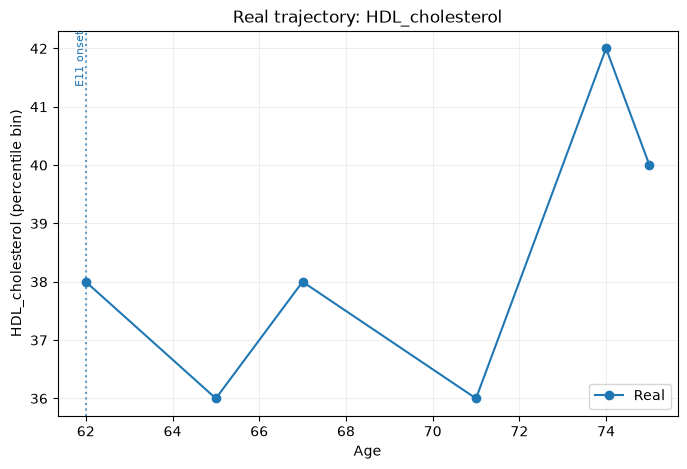

In [88]:
plot_real_vs_generated(real_seq=example_sequence, generated_seq=None, lab="HDL_cholesterol", disease="E11")

# Training

In the previous notebook, we used `EIR-auto-GP` to run a prediction on individual level genotype data with a pre-trained model. Under the hood, `EIR-auto-GP` is using `EIR` for this functionality. Now, we will go one layer down and work with `EIR` itself to train our own model.

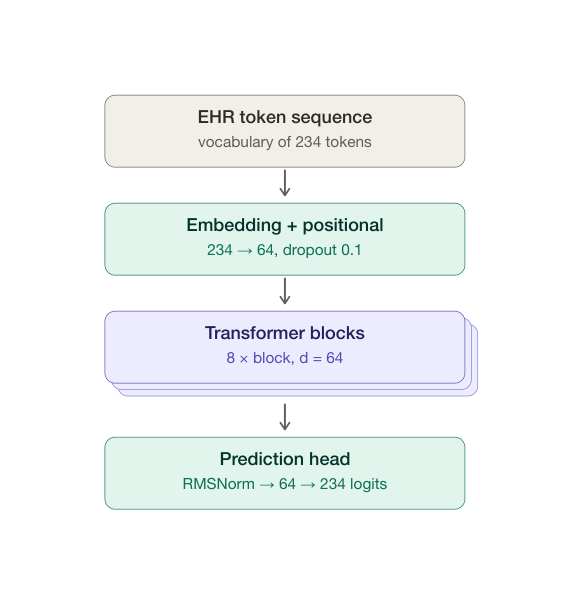

In [53]:
import fitz  
from IPython.display import Image, display

doc = fitz.open("../docs/static/figures/ehr-transformer.pdf")
page = doc.load_page(0) 
pix = page.get_pixmap(dpi=150)

display(Image(data=pix.tobytes()))

In [93]:
!cat ../configs/eir-transformer/output_sequence.yaml

output_info:
  output_source: ../reference_data/eir-transformer/df_ehr.csv
  output_name: ehr
  output_type: sequence

model_config:
  embedding_dim: 64
  model_init_config:
    num_layers: 4

output_type_info:
        sampling_strategy_if_longer: "uniform"
        max_length: 64
        split_on: " "
        min_freq: 10

> **Note**: A little quirk of EIR when doing sequence generation and only an output configuration is passed in is that it will "clone" the output configuration and use the supplied parameters to set up the earlier parts of the model, that is why we have 8 Transformer blocks in the diagram above, even though we only passed in 4 here for `num_layers`.

In [9]:
!eirtrain \
    --global_configs "../configs/eir-transformer/globals.yaml" \
    --fusion_configs "../configs/eir-transformer/fusion.yaml" \
    --output_configs "../configs/eir-transformer/output_sequence.yaml"

14:58:41 - INFO - eir.train_utils.utils - Global random seed set to 0.
14:58:41 - INFO - eir.setup.config_setup_modules.output_config_initialization - Output model type not specified in model configuration with name 'ehr', attempting to grab default value.
14:58:41 - INFO - eir.setup.streaming_data_setup.streaming_data_adapters - No streaming setup detected. Proceeding with standard data loading.
14:58:41 - INFO - eir.data_load.label_setup - Doing a manual split into validation set with 1400 IDs read from file.
14:58:41 - INFO - eir.target_setup.target_label_setup - Setting up target labels.
14:58:41 - INFO - eir.target_setup.target_label_setup - Setting up target labels for ehr.
Progress: 11200it [00:00, 6883969.05it/s]
14:58:41 - INFO - eir.target_setup.target_label_setup - Checking for missing target information. These will be ignored during loss and metric computation.
14:58:41 - INFO - eir.target_setup.target_label_setup - Output modality 'ehr' has no missing target IDs.
14:58:41 

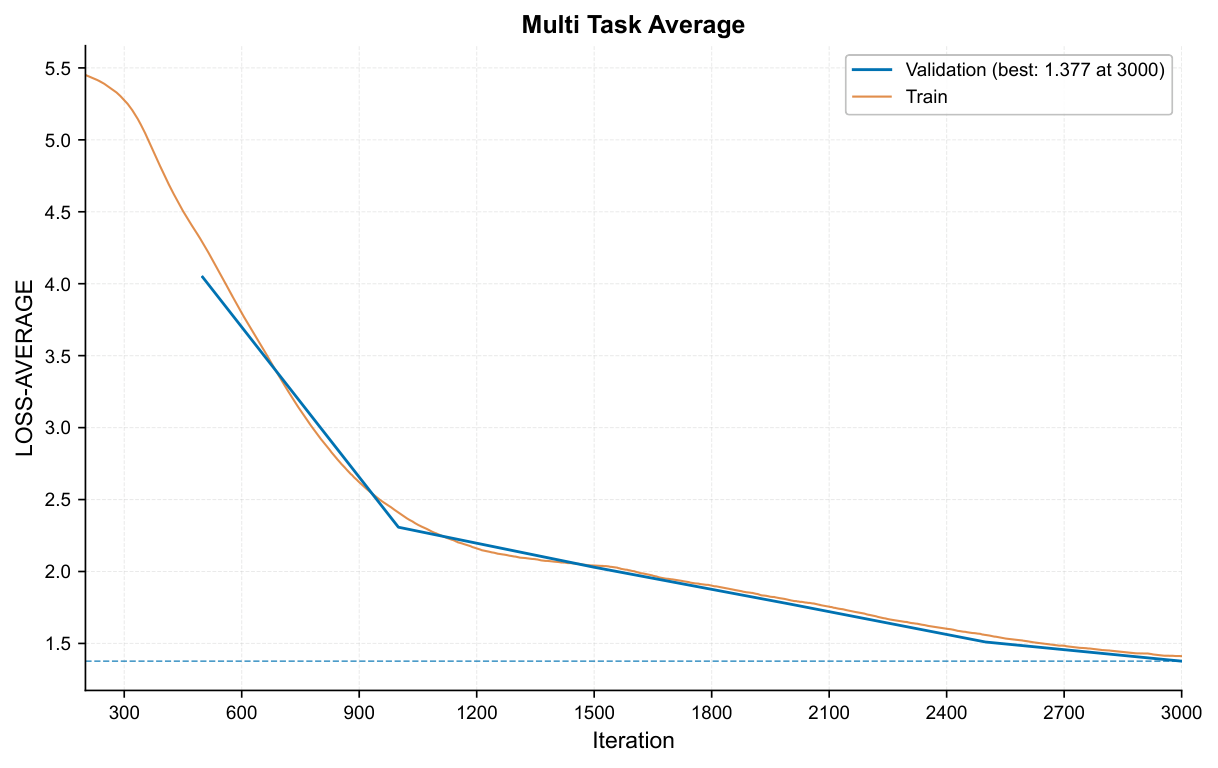

In [10]:
import fitz  
from IPython.display import Image, display

doc = fitz.open("../runs/ehr_transformer/training_curve_LOSS-AVERAGE.pdf")
page = doc.load_page(0) 
pix = page.get_pixmap(dpi=150)

display(Image(data=pix.tobytes()))

# Testing sequence generation

In [11]:
df_test_first_visit = pd.read_csv("../reference_data/eir-transformer/df_ehr_test_first_visit.csv", index_col=["ID"])

In [12]:
test_sample_index = 0

In [13]:
df_test_first_visit.iloc[test_sample_index].Sequence

'SEX_2 [VISIT_START] AGE_59 LAB_HDL_cholesterol_92% LAB_LDL_Cholesterol_84% LAB_Total_Triglycerides_22% DX_I25 [VISIT_END]'

In [14]:
prompt = df_test_first_visit["Sequence"].iloc[test_sample_index]
current_id = df_test_first_visit.index[test_sample_index]
print(prompt)

SEX_2 [VISIT_START] AGE_59 LAB_HDL_cholesterol_92% LAB_LDL_Cholesterol_84% LAB_Total_Triglycerides_22% DX_I25 [VISIT_END]


In [15]:
set_manual_inputs(prompts=prompt)

In [19]:
!eirpredict \
    --global_configs "../configs/eir-transformer/globals.yaml" \
    --output_configs "../configs/eir-transformer/output_sequence_test.yaml" \
    --model_path ../runs/ehr_transformer/saved_models/ehr_transformer_* \
    --output_folder "../runs/ehr_transformer/test_set_predictions"

15:33:10 - INFO - eir.train_utils.utils - Global random seed set to 0.
15:33:10 - INFO - eir.setup.config - Skipping input config name check for sequence input config (name='ehr') as it was automatically generated from a sequence output.
15:33:10 - INFO - eir.train_utils.metrics - Tabular output performance averaging functions across tasks set to averages of ['MCC', 'ROC-AUC-MACRO', 'AP-MACRO'] for categorical targets and ['1.0-LOSS', 'PCC', 'R2'] for continuous targets. These values are used to determine overall performance (using the validation set), which is used to control factors such as early stopping and LR scheduling. Other output cases (e.g. sequence generation, image generation) use 1.0-LOSS by default.
15:33:10 - DEBUG - eir.train_utils.metrics - All metrics are validation-only metrics, will skip all metric calculation for training batches.
15:33:10 - INFO - eir.setup.input_setup_modules.setup_sequence - Vocabulary for None will be collected from vocabulary file ../runs/ehr_

## Analyzing test performance

In [20]:
with open("../runs/ehr_transformer/test_set_predictions/results/ehr/ehr/samples/0/manual/10_generated.txt") as infile:
    generated = infile.read()

In [21]:
generated

'SEX_2 [VISIT_START] AGE_59 LAB_HDL_cholesterol_92% LAB_LDL_Cholesterol_84% LAB_Total_Triglycerides_22% DX_I25 [VISIT_END] [SEP] [VISIT_START] AGE_60 LAB_HDL_cholesterol_94% LAB_LDL_Cholesterol_96% LAB_Total_Triglycerides_24% DX_I25 [VISIT_END] [SEP] [VISIT_START] AGE_62 LAB_HDL_cholesterol_98% LAB_LDL_Cholesterol_98% LAB_Total_Triglycerides_30% DX_I25 [VISIT_END]'

In [22]:
df_test_full = pd.read_csv("../reference_data/eir-transformer/df_ehr_test.csv", index_col=["ID"])

In [23]:
df_test_full.loc[current_id]["Sequence"]

'SEX_2 [VISIT_START] AGE_59 LAB_HDL_cholesterol_92% LAB_LDL_Cholesterol_84% LAB_Total_Triglycerides_22% DX_I25 [VISIT_END] [SEP] [VISIT_START] AGE_61 LAB_HDL_cholesterol_96% LAB_LDL_Cholesterol_88% LAB_Total_Triglycerides_26% DX_I10 DX_I25 [VISIT_END] [SEP] [VISIT_START] AGE_64 LAB_HDL_cholesterol_98% LAB_LDL_Cholesterol_90% LAB_Total_Triglycerides_22% DX_I25 [VISIT_END] [SEP] [VISIT_START] AGE_65 LAB_HDL_cholesterol_96% LAB_LDL_Cholesterol_88% LAB_Total_Triglycerides_24% DX_I10 DX_I25 [VISIT_END] [SEP] [VISIT_START] AGE_66 LAB_HDL_cholesterol_94% LAB_LDL_Cholesterol_90% LAB_Total_Triglycerides_26% DX_I10 DX_I25 [VISIT_END] [SEP] [VISIT_START] AGE_68 LAB_HDL_cholesterol_96% LAB_LDL_Cholesterol_90% LAB_Total_Triglycerides_22% DX_I10 [VISIT_END] [SEP] [VISIT_START] AGE_69 LAB_HDL_cholesterol_98% LAB_LDL_Cholesterol_86% LAB_Total_Triglycerides_28% DX_I10 DX_I25 [VISIT_END]'

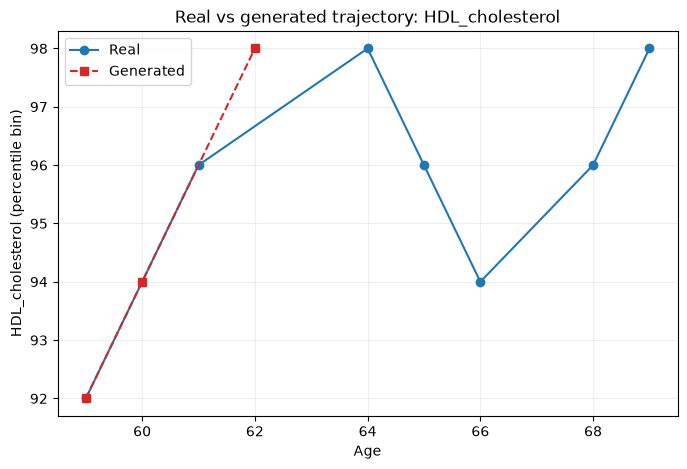

In [24]:
real_seq = df_test_full.loc[current_id]["Sequence"]
plot_real_vs_generated(real_seq=real_seq, generated_seq=generated, lab="HDL_cholesterol", disease="E11")

# Training with GRS as additional inputs

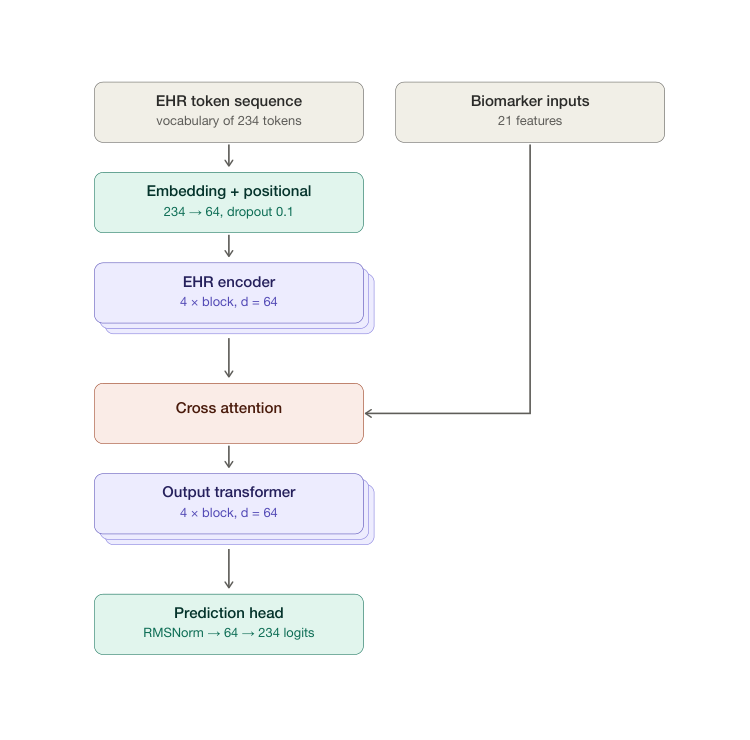

In [54]:
import fitz  
from IPython.display import Image, display

doc = fitz.open("../docs/static/figures/ehr-transformer-with-grs.pdf")
page = doc.load_page(0) 
pix = page.get_pixmap(dpi=150)

display(Image(data=pix.tobytes()))

In [25]:
series_list, kinds = [], {}
for p in sorted(RESULTS_DIR.glob("*.csv")):
  s = load_trait_csv(p)
  series_list.append(s)
  kinds[s.name] = s.attrs["kind"]

df_grs = pd.concat(series_list, axis=1)
trait_kind = pd.Series(kinds, name="kind")
print(f"preds: {df_grs.shape}  continuous={(trait_kind=='continuous').sum()}  binary={(trait_kind=='binary').sum()}")

df_grs.index = df_grs.index.astype(str)

display(df_grs.head())

preds: (1401, 315)  continuous=237  binary=78


,Alanine_aminotransferase,Albumin_BIOCH,Alkaline_phosphatase,Apolipoprotein_A,Apolipoprotein_A1,Apolipoprotein_B_BIOCH,Apolipoprotein_B_METAB,Aspartate_aminotransferase,Average_Diameter_for_HDL_Particles,Average_Diameter_for_VLDL_Particles,...,Urea,VLDL_Cholesterol,Vitamin_D,Waist_circumference,Weight_ANTHRO,Weight_IMPED,White_blood_cell_leukocyte_count,Whole_body_fat_free_mass,Whole_body_fat_mass,Whole_body_water_mass
ID,,,,,,,,,,,,,,,,,,,,,
10002,22.542770,45.750916,78.095764,1.516815,1.461326,1.079866,0.920252,25.107138,9.593956,38.873093,...,5.371122,0.798058,49.158367,92.140720,80.53792,80.50510,6.893251,54.358200,26.746830,39.798134
10004,28.100965,44.744290,82.361740,1.553589,1.489705,0.935423,0.784924,26.449203,9.604637,38.699020,...,5.384340,0.621664,46.077310,88.349655,76.54702,76.31497,6.289234,52.096508,23.333853,37.992413
10005,22.484833,45.355780,90.182304,1.544894,1.473571,1.035341,0.870705,27.218803,9.558011,39.674297,...,5.420731,0.774767,50.846190,90.930595,76.09740,75.78765,6.923183,51.953290,26.081810,37.976200
10007,23.979660,45.518280,87.363410,1.639348,1.566334,1.016251,0.852204,24.755083,9.717243,38.340710,...,5.477870,0.692197,45.338993,87.590614,70.78200,70.52157,6.385489,49.508488,22.894983,36.236700
10008,26.343996,46.066658,88.195015,1.447073,1.392570,1.073851,0.893995,26.636324,9.563436,38.972090,...,5.484081,0.751684,54.548225,87.538030,78.50737,78.36777,6.650043,52.501266,23.214048,38.252075


In [26]:
df_seq_test = pd.read_csv("../reference_data/eir-transformer/df_ehr_test.csv", index_col="ID")

In [27]:
df_seq = pd.concat([df_seq_train, df_seq_test])

In [28]:
df_seq_test

,Sequence
ID,
10027_0,SEX_2 [VISIT_START] AGE_59 LAB_HDL_cholesterol...
10027_1,SEX_2 [VISIT_START] AGE_58 LAB_HDL_cholesterol...
10027_2,SEX_2 [VISIT_START] AGE_59 LAB_HDL_cholesterol...
10027_3,SEX_2 [VISIT_START] AGE_59 LAB_HDL_cholesterol...
10027_4,SEX_2 [VISIT_START] AGE_58 LAB_HDL_cholesterol...
...,...
11591_5,SEX_2 [VISIT_START] AGE_62 LAB_HDL_cholesterol...
11591_6,SEX_2 [VISIT_START] AGE_61 LAB_HDL_cholesterol...
11591_7,SEX_2 [VISIT_START] AGE_60 LAB_HDL_cholesterol...


In [29]:
import pandas as pd
import numpy as np

df_seq['base_id'] = df_seq.index.str.split('_').str[0]

df_expanded = df_seq[['base_id']].merge(
    df_grs, 
    left_on='base_id', 
    right_index=True, 
    how='left'
)

numeric_cols = df_expanded.select_dtypes(include=[np.number]).columns

noise_factor = 0.01 

for col in numeric_cols:
    noise = np.random.normal(0, df_expanded[col].std() * noise_factor, size=len(df_expanded))
    df_expanded[col] = df_expanded[col] + noise

df_grs_matched = df_expanded.drop(columns=['base_id'])

In [30]:
df_grs_train = df_grs_matched[df_grs_matched.index.isin(df_seq_train.index)]
df_grs_test = df_grs_matched[df_grs_matched.index.isin(df_seq_test.index)]

In [31]:
df_grs_train.to_csv("../reference_data/eir-transformer/df_grs.csv")
df_grs_test.to_csv("../reference_data/eir-transformer/df_grs_test.csv")

In [32]:
import yaml

all_columns = [
    "Cholesterol",                    
    "LDL_direct",                     
    "Glycated_haemoglobin_HbA1c",     
    "Alanine_aminotransferase",
    "Aspartate_aminotransferase",
    "Gamma_glutamyltransferase",
    "Alkaline_phosphatase",
    "Albumin_BIOCH",
    "Total_protein",
    "Direct_bilirubin",
    "Total_bilirubin",
    "C_reactive_protein",
    "Urate",
    "Calcium",
    "Phosphate",
    "Creatinine_BIOCH",
    "Cystatin_C",
    "Urea",
    "IGF_1",
    "Vitamin_D",
    "Lipoprotein_A",
]

config = {
    'input_info': {
        'input_source': '../reference_data/eir-transformer/df_grs.csv',
        'input_name': 'biomarker_inputs',
        'input_type': 'tabular'
    },
    'input_type_info': {
        'input_con_columns': all_columns 
    },
    'model_config': {
        'model_type': 'tabular'
    }
}

with open('../configs/eir-transformer-with-grs/input_tabular.yaml', 'w') as f:
    yaml.dump(config, f, sort_keys=False, default_flow_style=False)

In [33]:
config = {
    'input_info': {
        'input_source': '../reference_data/eir-transformer/df_grs_test.csv',
        'input_name': 'biomarker_inputs',
        'input_type': 'tabular'
    },
    'input_type_info': {
        'input_con_columns': all_columns 
    },
    'model_config': {
        'model_type': 'tabular'
    }
}

with open('../configs/eir-transformer-with-grs/input_tabular_test.yaml', 'w') as f:
    yaml.dump(config, f, sort_keys=False, default_flow_style=False)

In [34]:
!eirtrain \
    --global_configs "../configs/eir-transformer-with-grs/globals.yaml" \
    --input_configs  "../configs/eir-transformer-with-grs/input_tabular.yaml" \
    --fusion_configs "../configs/eir-transformer/fusion.yaml" \
    --output_configs "../configs/eir-transformer-with-grs/output_sequence.yaml"

15:34:46 - INFO - eir.train_utils.utils - Global random seed set to 0.
15:34:46 - INFO - eir.setup.config_setup_modules.output_config_initialization - Output model type not specified in model configuration with name 'ehr', attempting to grab default value.
15:34:47 - INFO - eir.setup.streaming_data_setup.streaming_data_adapters - No streaming setup detected. Proceeding with standard data loading.
15:34:47 - INFO - eir.data_load.label_setup - Doing a manual split into validation set with 1400 IDs read from file.
15:34:47 - INFO - eir.target_setup.target_label_setup - Setting up target labels.
15:34:47 - INFO - eir.target_setup.target_label_setup - Setting up target labels for ehr.
Progress: 11200it [00:00, 6888006.57it/s]
15:34:47 - INFO - eir.target_setup.target_label_setup - Checking for missing target information. These will be ignored during loss and metric computation.
15:34:47 - INFO - eir.target_setup.target_label_setup - Output modality 'ehr' has no missing target IDs.
15:34:47 

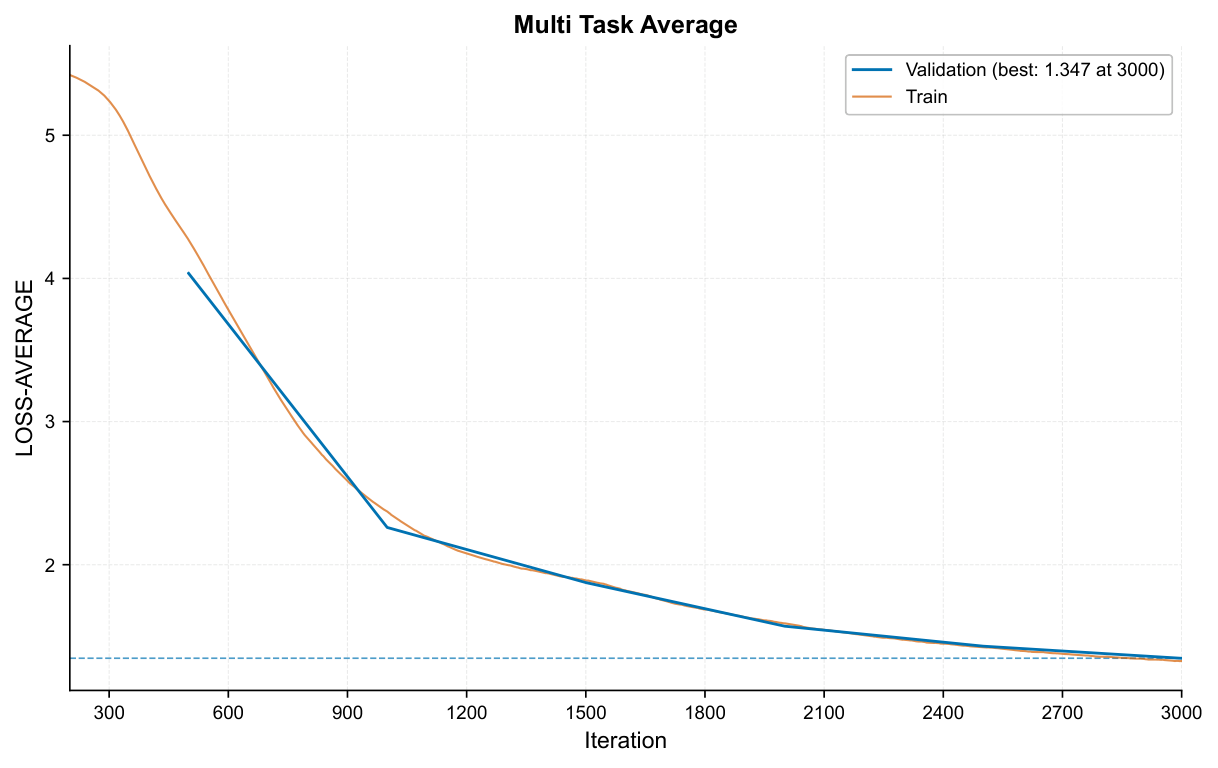

In [35]:
import fitz  
from IPython.display import Image, display

doc = fitz.open("../runs/ehr_transformer-with-grs/training_curve_LOSS-AVERAGE.pdf")
page = doc.load_page(0) 
pix = page.get_pixmap(dpi=150)

display(Image(data=pix.tobytes()))

# Testing with GRS input

In [36]:
df_test_first_visit = pd.read_csv("../reference_data/eir-transformer/df_ehr_test_first_visit.csv", index_col=["ID"])

In [37]:
test_sample_index = 0

In [38]:
df_test_first_visit.iloc[test_sample_index].Sequence

'SEX_2 [VISIT_START] AGE_59 LAB_HDL_cholesterol_92% LAB_LDL_Cholesterol_84% LAB_Total_Triglycerides_22% DX_I25 [VISIT_END]'

In [39]:
prompt = df_test_first_visit["Sequence"].iloc[test_sample_index]
current_id = df_test_first_visit.index[test_sample_index]
print(prompt)

SEX_2 [VISIT_START] AGE_59 LAB_HDL_cholesterol_92% LAB_LDL_Cholesterol_84% LAB_Total_Triglycerides_22% DX_I25 [VISIT_END]


In [40]:
current_base_id = current_id.split("_")[0]
tabular_input = df_grs.loc[current_base_id, all_columns].to_dict()

In [41]:
tabular_input

{'Cholesterol': 6.1145873,
 'LDL_direct': 3.7932913,
 'Glycated_haemoglobin_HbA1c': 36.74147,
 'Alanine_aminotransferase': 26.33017,
 'Aspartate_aminotransferase': 27.550787,
 'Gamma_glutamyltransferase': 38.039497,
 'Alkaline_phosphatase': 79.44806,
 'Albumin_BIOCH': 45.703136,
 'Total_protein': 71.72162,
 'Direct_bilirubin': 3.3085146,
 'Total_bilirubin': 19.51425,
 'C_reactive_protein': 2.1354516,
 'Urate': 301.092,
 'Calcium': 2.3919413,
 'Phosphate': 1.1971753,
 'Creatinine_BIOCH': 75.11925,
 'Cystatin_C': 0.8391408,
 'Urea': 5.454428,
 'IGF_1': 20.052748,
 'Vitamin_D': 49.109905,
 'Lipoprotein_A': 40.112858}

In [42]:
set_manual_inputs(prompts=prompt,
                  config_path="../configs/eir-transformer-with-grs/output_sequence_test.yaml",
                  tabular=tabular_input)

In [43]:
!eirpredict \
    --global_configs "../configs/eir-transformer-with-grs/globals.yaml" \
    --input_configs "../configs/eir-transformer-with-grs/input_tabular_test.yaml" \
    --output_configs "../configs/eir-transformer-with-grs/output_sequence_test.yaml" \
    --model_path ../runs/ehr_transformer-with-grs/saved_models/ehr_transformer-with-grs_checkpoint_* \
    --output_folder "../runs/ehr_transformer-with-grs/test_set_predictions" 

15:38:31 - INFO - eir.train_utils.utils - Global random seed set to 0.
15:38:31 - INFO - eir.setup.config - Skipping input config name check for sequence input config (name='ehr') as it was automatically generated from a sequence output.
15:38:31 - INFO - eir.train_utils.metrics - Tabular output performance averaging functions across tasks set to averages of ['MCC', 'ROC-AUC-MACRO', 'AP-MACRO'] for categorical targets and ['1.0-LOSS', 'PCC', 'R2'] for continuous targets. These values are used to determine overall performance (using the validation set), which is used to control factors such as early stopping and LR scheduling. Other output cases (e.g. sequence generation, image generation) use 1.0-LOSS by default.
15:38:31 - DEBUG - eir.train_utils.metrics - All metrics are validation-only metrics, will skip all metric calculation for training batches.
15:38:31 - INFO - eir.setup.input_setup_modules.setup_sequence - Vocabulary for None will be collected from vocabulary file ../runs/ehr_

In [44]:
with open("../runs/ehr_transformer-with-grs/test_set_predictions/results/ehr/ehr/samples/0/manual/0_generated.txt") as infile:
    generated = infile.read()

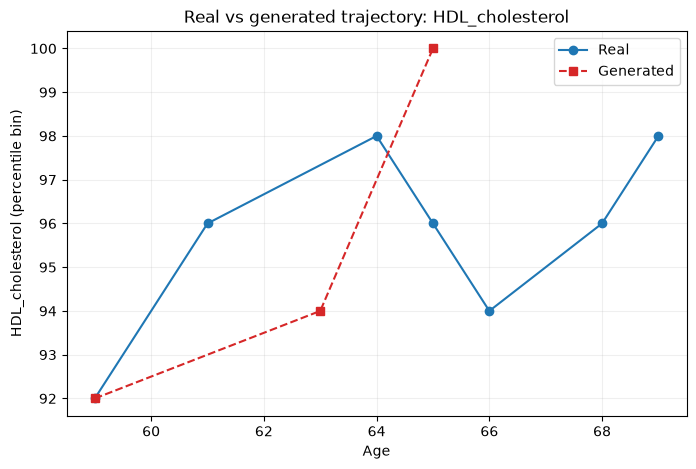

In [45]:
real_seq = df_test_full.loc[current_id]["Sequence"]
plot_real_vs_generated(real_seq=real_seq, generated_seq=generated, lab="HDL_cholesterol", disease="E11")